In [1]:
import torch
print(torch.__version__)
print("torch available",torch.cuda.is_available())

2.10.0+cu128
torch available True


In [4]:
import torchvision
import torchvision.transforms as transforms

# Transform images to tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download and load training data
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)

# Download and load test data
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)

print("Training images:", len(trainset))
print("Test images:", len(testset))

Training images: 50000
Test images: 10000


In [5]:
from torch.utils.data import DataLoader

trainloader=DataLoader(trainset,batch_size=32,shuffle=True)
testloader=DataLoader(testset,batch_size=32,shuffle=True)

print("Number of training batches:",len(trainloader))
print("Number of test batches:", len(testloader))

Number of training batches: 1563
Number of test batches: 313


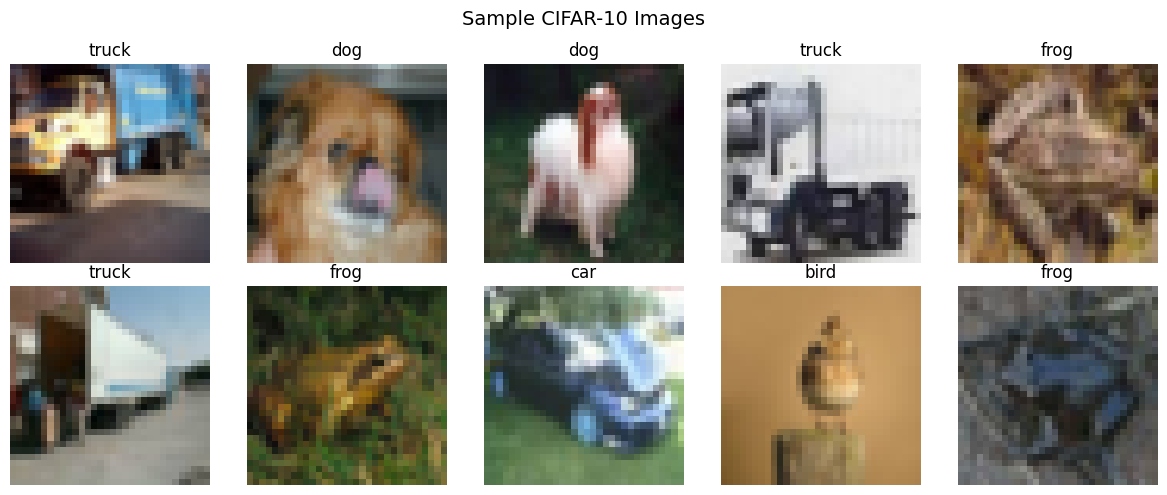

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Class names
classes = ['airplane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Get one batch of images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Plot 10 images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img = images[i]
    img = img / 2 + 0.5  # unnormalize back to 0-1
    img = img.numpy().transpose((1, 2, 0))  # convert to HWC format for matplotlib
    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')

plt.suptitle('Sample CIFAR-10 Images', fontsize=14)
plt.tight_layout()
plt.show()